# Optiver realized volatility: baseline vs. engineered-feature models

Naive realized-volatility baseline vs. linear regression, LightGBM, and XGBoost on windowed order-book/trade features.

For every model: **train** error bars come from 5-fold blocked cross-validation over `time_id`; **test** error bars come from a 100-sample bootstrap of the held-out predictions.

In [1]:
import sys
sys.path.append("../../src")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from optiver_volatility import optiver_utils as ou

DATA_DIR = Path("../../data/optiver_volatility")
N_WINDOWS = 20
N_SPLITS = 5
N_BOOT = 100

train = pd.read_csv(DATA_DIR / "train.csv")
stock_ids = sorted(train["stock_id"].unique())
train_time_ids, test_time_ids = ou.split_time_ids(train["time_id"].unique(), frac=0.5)

print(f"train: {train.shape[0]:,} rows | {len(stock_ids)} stocks | {train['time_id'].nunique():,} time_ids")
print(f"train_time_ids: {len(train_time_ids):,} | test_time_ids: {len(test_time_ids):,}")

train: 428,932 rows | 112 stocks | 3,830 time_ids
train_time_ids: 1,915 | test_time_ids: 1,915


## Data overview

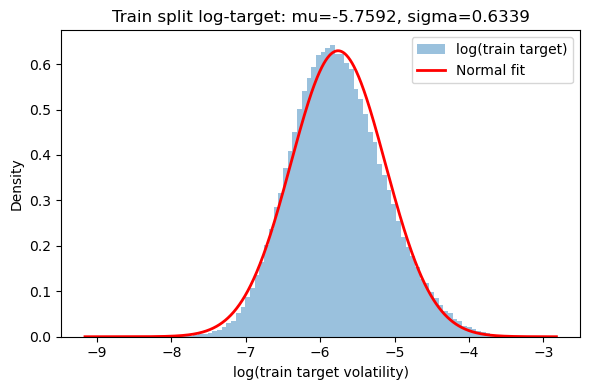

In [2]:
# Distribution of the target volatility (train split), in log space
target_train = train.loc[train["time_id"].isin(train_time_ids), "target"].dropna()
log_target = np.log(target_train)
mu, sigma = norm.fit(log_target)
log_x = np.linspace(log_target.min(), log_target.max(), 1000)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(log_target, bins=100, density=True, alpha=0.45, label="log(train target)")
ax.plot(log_x, norm.pdf(log_x, mu, sigma), color="red", linewidth=2, label="Normal fit")
ax.set_xlabel("log(train target volatility)")
ax.set_ylabel("Density")
ax.set_title(f"Train split log-target: mu={mu:.4f}, sigma={sigma:.4f}")
ax.legend()
plt.tight_layout()
plt.show()

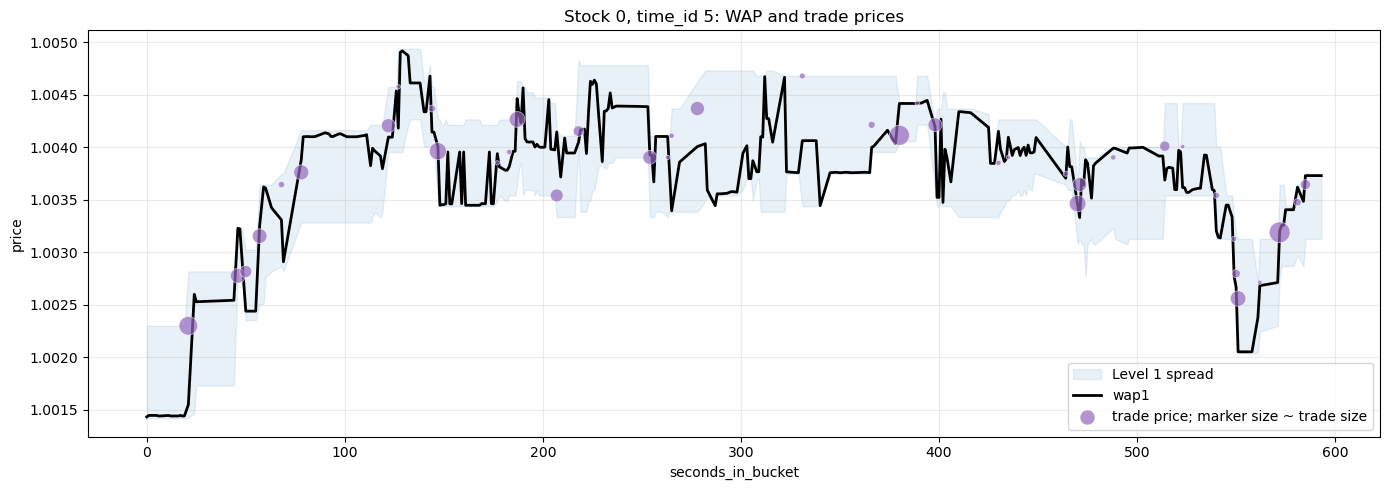

In [3]:
# WAP and trade prices for one example stock/time_id bucket
example_stock_id = 0
example_time_id = train_time_ids[0]

book = ou.load_book(example_stock_id, DATA_DIR)
trade = ou.load_trade(example_stock_id, DATA_DIR)

book_slice = book[book["time_id"] == example_time_id].copy()
trade_slice = trade[trade["time_id"] == example_time_id].copy()
book_slice["wap1"] = ou.compute_wap(book_slice, level=1)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(
    book_slice["seconds_in_bucket"], book_slice["bid_price1"], book_slice["ask_price1"],
    color="tab:blue", alpha=0.10, label="Level 1 spread",
)
ax.plot(book_slice["seconds_in_bucket"], book_slice["wap1"], color="black", linewidth=2.0, label="wap1")

if not trade_slice.empty:
    trade_sizes = np.sqrt(trade_slice["size"].clip(lower=1)) * 10
    ax.scatter(
        trade_slice["seconds_in_bucket"], trade_slice["price"], s=trade_sizes,
        color="tab:purple", alpha=0.70, edgecolors="white", linewidths=0.5,
        label="trade price; marker size ~ trade size", zorder=5,
    )

ax.set_title(f"Stock {example_stock_id}, time_id {example_time_id}: WAP and trade prices")
ax.set_xlabel("seconds_in_bucket")
ax.set_ylabel("price")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## Baseline: naive realized volatility

Realized volatility of the whole 10-minute-bucket `wap1` log-returns, with no fitting.

In [4]:
baseline_pred = ou.naive_rv_baseline(stock_ids, DATA_DIR, train)

baseline_cv_scores = ou.cv_scores_baseline(baseline_pred, train_time_ids, n_splits=N_SPLITS)

baseline_test = baseline_pred[baseline_pred["time_id"].isin(test_time_ids)]
baseline_boot_scores = ou.bootstrap_scores(baseline_test, "target", "pred", n_boot=N_BOOT)

print(f"baseline train CV   rmspe: {baseline_cv_scores.mean():.4f} +/- {baseline_cv_scores.std():.4f}")
print(f"baseline test boot  rmspe: {baseline_boot_scores.mean():.4f} +/- {baseline_boot_scores.std():.4f}")

baseline train CV   rmspe: 0.3381 +/- 0.0086
baseline test boot  rmspe: 0.3437 +/- 0.0051


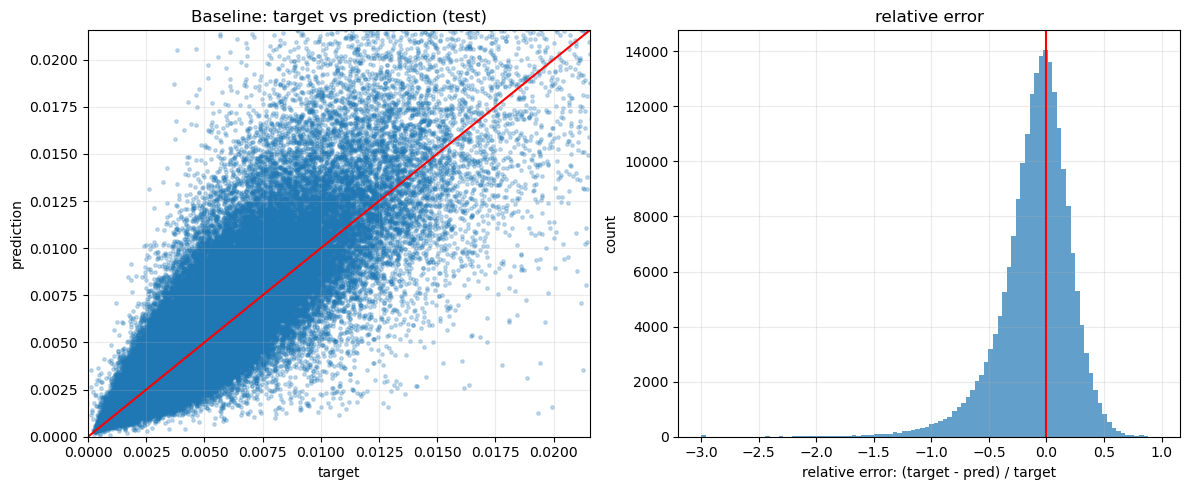

In [5]:
_ = ou.plot_prediction_diagnostics(
    baseline_test["target"], baseline_test["pred"], title="Baseline: target vs prediction (test)",
)

## Feature engineering

Each 10-minute bucket is split into `N_WINDOWS` equal sub-windows; book/trade features are computed independently per sub-window, plus cross-sectional market mean/std features per window.

In [6]:
all_features, feature_cols = ou.build_feature_matrix(stock_ids, DATA_DIR, n_windows=N_WINDOWS)

data_all = all_features.merge(train[["stock_id", "time_id", "target"]], on=["stock_id", "time_id"], how="inner")
data_all = data_all.dropna(subset=feature_cols)

train_all = data_all[data_all["time_id"].isin(train_time_ids)]
test_all = data_all[data_all["time_id"].isin(test_time_ids)]

print(f"features: {len(feature_cols)} | train rows: {len(train_all):,} | test rows: {len(test_all):,}")

features: 260 | train rows: 204,491 | test rows: 204,250


## Model comparison: baseline vs. linear vs. LightGBM vs. XGBoost

In [7]:
from sklearn.linear_model import LinearRegression
import lightgbm as lgb
import xgboost as xgb

model_factories = {
    "linear": lambda: LinearRegression(),
    "lightgbm": lambda: lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, reg_lambda=1.0, random_state=42, verbosity=-1,
    ),
    "xgboost": lambda: xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0,
    ),
}

In [8]:
results = {"baseline": ou.summarize_scores("baseline", baseline_cv_scores, baseline_boot_scores)}
test_predictions = {"baseline": baseline_test[["target", "pred"]].copy()}

label = "baseline"
print(f"{label:10s} train CV rmspe: {baseline_cv_scores.mean():.4f} +/- {baseline_cv_scores.std():.4f} "
      f"| test boot rmspe: {baseline_boot_scores.mean():.4f} +/- {baseline_boot_scores.std():.4f}")

for name, factory in model_factories.items():
    cv_scores = ou.cv_scores_model(factory, train_all, feature_cols, train_time_ids, n_splits=N_SPLITS)
    test_pred = ou.fit_predict(factory, train_all, test_all, feature_cols)
    pred_df = pd.DataFrame({"target": test_all["target"].to_numpy(), "pred": test_pred})
    boot_scores = ou.bootstrap_scores(pred_df, "target", "pred", n_boot=N_BOOT)

    results[name] = ou.summarize_scores(name, cv_scores, boot_scores)
    test_predictions[name] = pred_df

    print(f"{name:10s} train CV rmspe: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f} "
          f"| test boot rmspe: {boot_scores.mean():.4f} +/- {boot_scores.std():.4f}")

summary = pd.DataFrame(results.values())
summary

baseline   train CV rmspe: 0.3381 +/- 0.0086 | test boot rmspe: 0.3437 +/- 0.0051


linear     train CV rmspe: 0.2364 +/- 0.0021 | test boot rmspe: 0.2395 +/- 0.0041


lightgbm   train CV rmspe: 0.2329 +/- 0.0034 | test boot rmspe: 0.2367 +/- 0.0035


xgboost    train CV rmspe: 0.2410 +/- 0.0076 | test boot rmspe: 0.2446 +/- 0.0054


,model,train_rmspe_mean,train_rmspe_std,test_rmspe_mean,test_rmspe_std
0,baseline,0.338076,0.008576,0.343726,0.005097
1,linear,0.236398,0.002136,0.239475,0.004144
2,lightgbm,0.232923,0.003385,0.236681,0.003494
3,xgboost,0.240976,0.007636,0.244563,0.005399


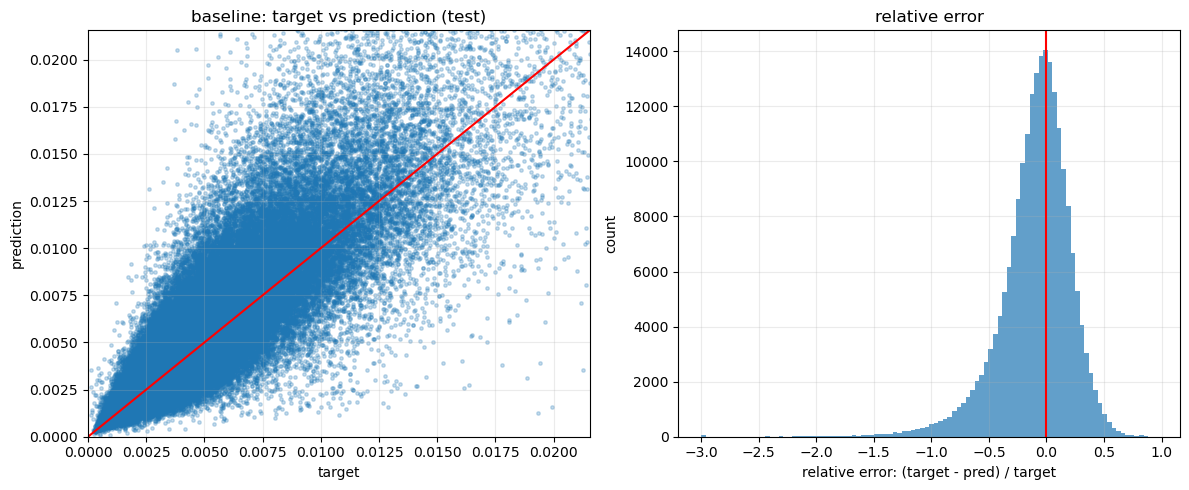

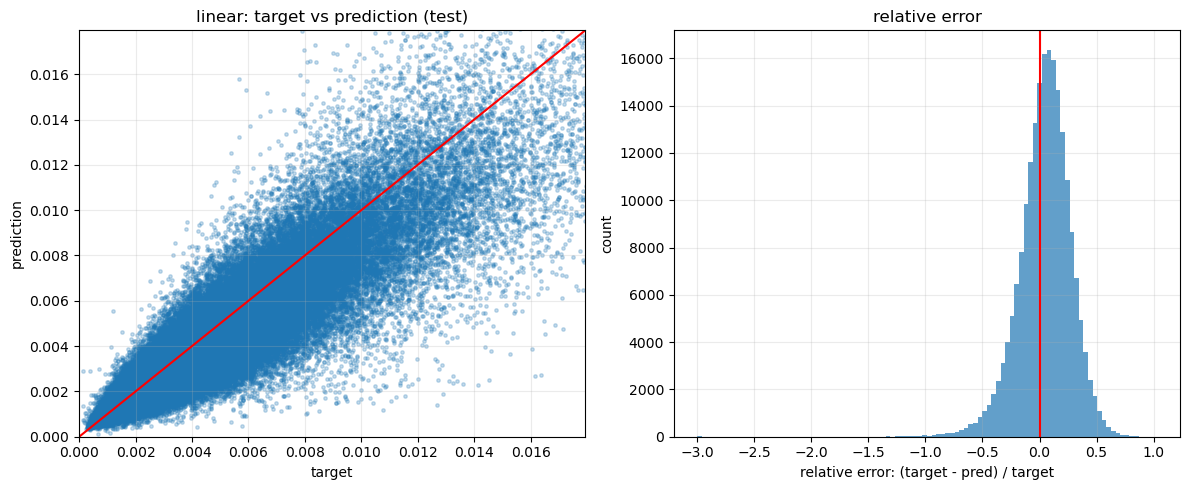

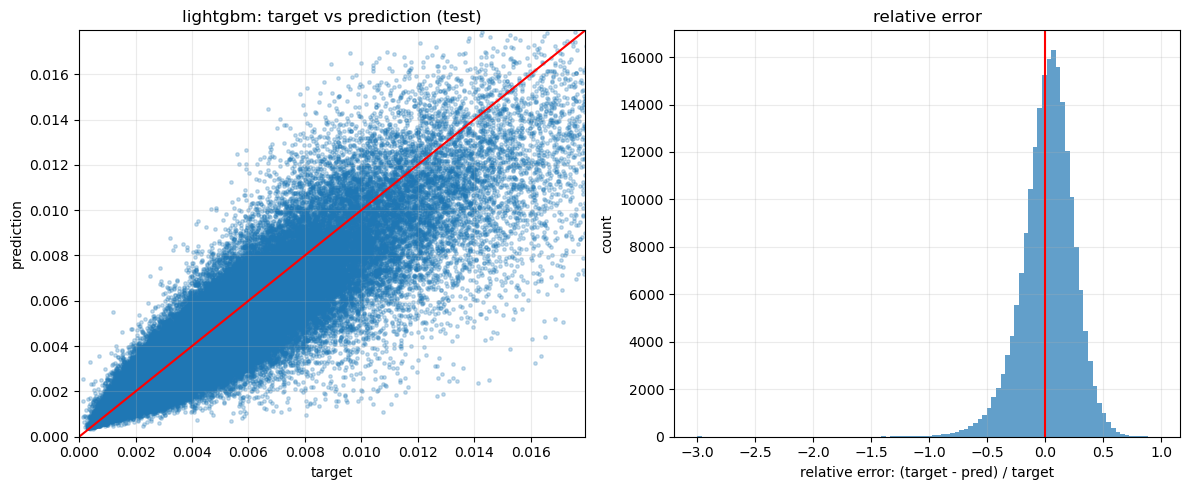

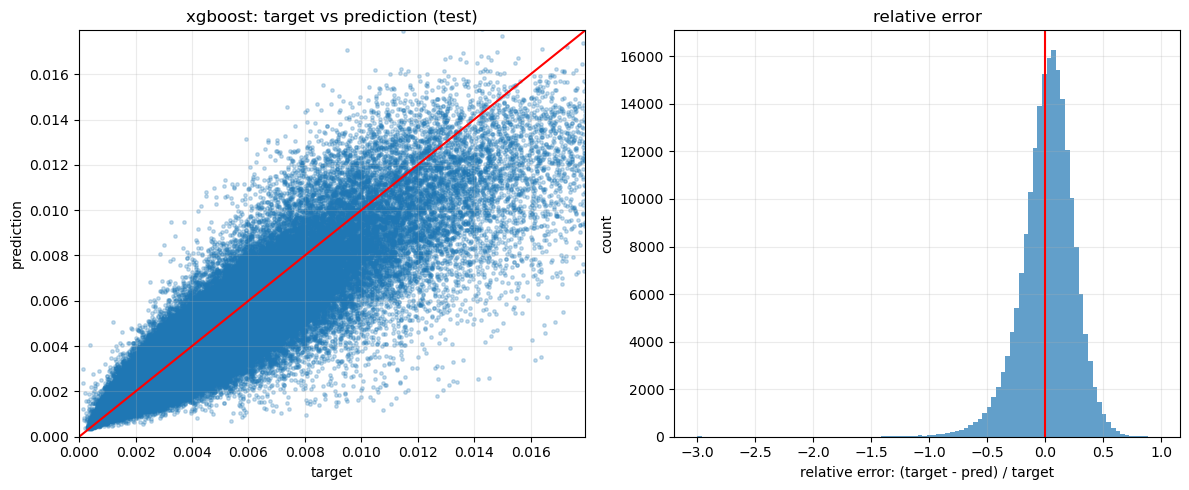

In [9]:
for name, pred_df in test_predictions.items():
    _ = ou.plot_prediction_diagnostics(
        pred_df["target"], pred_df["pred"], title=f"{name}: target vs prediction (test)",
    )

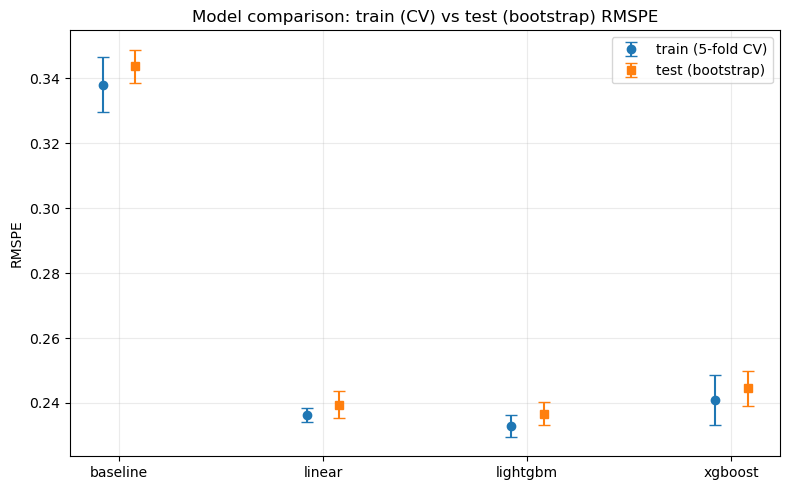

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(summary))
ax.errorbar(x - 0.08, summary["train_rmspe_mean"], yerr=summary["train_rmspe_std"],
            fmt="o", capsize=4, label="train (5-fold CV)")
ax.errorbar(x + 0.08, summary["test_rmspe_mean"], yerr=summary["test_rmspe_std"],
            fmt="s", capsize=4, label="test (bootstrap)")
ax.set_xticks(x)
ax.set_xticklabels(summary["model"])
ax.set_ylabel("RMSPE")
ax.set_title("Model comparison: train (CV) vs test (bootstrap) RMSPE")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()